In [7]:
import os
import json
import re
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Any, List, Optional

import pandas as pd
import matplotlib.pyplot as plt
from openai import OpenAI

# config ollama
client = OpenAI(
    api_key="ollama",
    base_url="http://localhost:11434/v1"
)

MODEL_NAME = "mistral:7b"


# =========================
# Utils filtres / bool
# =========================

def is_bool_series(s: pd.Series) -> bool:
    # detecte si une collone pandas peut etre traite comme un booléen
    if pd.api.types.is_bool_dtype(s):
        return True
    if s.dtype == "object":  # si c'est une colonne de type objet, on vérifie les valeurs possibles
        vals = set(s.dropna().unique().tolist())
        return vals.issubset({True, False, "True", "False", "true", "false", 0, 1, "0", "1"})
    return False


def coerce_bool_value(v: Any) -> Optional[bool]:
    # convertit une valeur en booléen si possible, sinon retourne None
    if v is None:
        return None
    if isinstance(v, bool):
        return v
    if isinstance(v, (int, float)) and v in (0, 1):
        return bool(int(v))
    if isinstance(v, str):
        t = v.strip().lower()
        if t in ("true", "vrai", "1", "yes", "y"):
            return True
        if t in ("false", "faux", "0", "no", "n"):
            return False
    return None


def safe_apply_filters(df: pd.DataFrame, filters: List[Dict[str, Any]]) -> pd.DataFrame:
    # applique des filtres en évitant les erreurs courantes
    if not filters:
        return df

    out = df.copy()  # on travaille sur une copie du df
    for f in filters:
        col = f.get("column")
        val = f.get("value")
        op = f.get("op", "==")

        if col not in out.columns:  # on verif que la colonne existe
            print(f"[filter] ignore: colonne inconnue {col}")
            continue

        s = out[col]

        # Bool : on force == True/False si possible
        if is_bool_series(s):
            b = coerce_bool_value(val)
            # si l'utilisateur n'a pas donné de valeur alors on filtre les True
            if b is None:
                b = True
            out = out[s.astype(str).str.lower().isin([str(b).lower()])]
            continue

        # Si valeur fournie, on vérifie qu'elle existe (pour éviter df vide)
        if val is not None:
            if pd.api.types.is_object_dtype(s) or pd.api.types.is_string_dtype(s):
                uniques = set(s.dropna().astype(str).unique().tolist())
                if str(val) not in uniques and op in ("==", None):
                    print(f"[filter] ignore: la valeur '{val}' n'est pas dans les valeurs uniques de {col}")
                    continue

        # applique le filtre en fonction de l'opérateur
        if op == "==" or op is None:
            out = out[out[col] == val]
        elif op == "!=":
            out = out[out[col] != val]
        elif op in (">", ">=", "<", "<="):
            sn = pd.to_numeric(out[col], errors="coerce")
            vn = pd.to_numeric(pd.Series([val]), errors="coerce").iloc[0]
            if pd.isna(vn):
                print(f"[filter] ignore: valeur non numérique pour opé numérique: {val}")
                continue
            if op == ">":
                out = out[sn > vn]
            elif op == ">=":
                out = out[sn >= vn]
            elif op == "<":
                out = out[sn < vn]
            elif op == "<=":
                out = out[sn <= vn]
        elif op == "contains":
            out = out[out[col].astype(str).str.contains(str(val), na=False)]
        elif op == "in" and isinstance(val, list):
            out = out[out[col].isin(val)]
        else:
            print(f"[filter] ignore: opération non supportée {op}")
            continue

    return out


# =========================
# Chargement JSONL -> DataFrame
# =========================

def flatten_json(obj, parent="", sep="_"):
    # aplatit un json imbriqué en dictionnaire à plat
    items = {}
    for k, v in obj.items():
        new_key = f"{parent}{sep}{k}" if parent else k
        if isinstance(v, dict):
            items.update(flatten_json(v, new_key, sep=sep))
        else:
            items[new_key] = v
    return items


def load_df(path: str, sample_rows: int = 5000):
    # charge les logs JSON en dataframe, ignore les lignes vides
    rows = []

    with open(path, "r", encoding="utf-8") as f:
        for i, line in enumerate(f):
            if i >= sample_rows:
                break
            line = line.strip()
            if not line:
                continue
            obj = json.loads(line)
            rows.append(flatten_json(obj))

    df = pd.DataFrame(rows)
    df.columns = df.columns.str.strip()  # nettoie les espaces dans les noms de colonnes
    return df


# =========================
# LLM Intent extraction
# =========================

INTENT_SYSTEM = """
You are a data visualization intent extractor.

Return ONLY valid JSON:

{
  "intent": "count" | "scatter" | "line" | "distribution" | "trend" | "time_series",
  "chart": "auto" | "bar" | "scatter" | "line",
  "group_by": string | null,
  "x": string | null,
  "y": string | null,
  "filter": [{"column": string, "value": any, "op": "==" | "!=" | ">" | ">=" | "<" | "<=" | "contains" | "in"}] | []
}

Rules:
- Use ONLY column names provided in SCHEMA.
- If user asks for "nombre", "combien", "count", "répartition", use intent="count" or "distribution" when relevant.
- Prefer chart="line" for temporal evolution / trend.
- Return JSON only.
"""


def extract_intent(prompt: str, df: pd.DataFrame) -> Dict[str, Any]:
    schema = list(df.columns)

    msg = f"""
SCHEMA:
{schema}

USER_PROMPT:
{prompt}
"""

    response = client.chat.completions.create(
        model=MODEL_NAME,
        messages=[
            {"role": "system", "content": INTENT_SYSTEM},
            {"role": "user", "content": msg},
        ],
        temperature=0.1
    )

    content = response.choices[0].message.content.strip()

    # nettoyage si besoin
    content = re.sub(r"^```(?:json)?", "", content).strip()
    content = re.sub(r"```$", "", content).strip()

    return json.loads(content)


# =========================
# Refactor modulaire plotting
# =========================

@dataclass
class PlotSpec:
    plot_type: str                   # "bar_count", "single_count", "scatter", "line"
    x: Optional[str] = None
    y: Optional[str] = None
    group_by: Optional[str] = None
    filters: Optional[List[Dict[str, Any]]] = None
    sort_by: Optional[str] = None    # "count", "x", "y"
    sort_ascending: bool = False


def normalize_intent(intent: Dict[str, Any]) -> Dict[str, Any]:
    out = dict(intent)

    out["chart"] = (out.get("chart") or "auto")
    if isinstance(out["chart"], str):
        out["chart"] = out["chart"].lower()

    if isinstance(out.get("intent"), str):
        out["intent"] = out["intent"].lower()

    out["filter"] = out.get("filter") or []

    return out


def build_plot_spec(df: pd.DataFrame, intent: Dict[str, Any]) -> PlotSpec:
    """
    Décide QUOI tracer (stratégie), sans tracer.
    """
    intent_n = normalize_intent(intent)

    chart = intent_n.get("chart", "auto")
    intent_type = intent_n.get("intent")
    group_by = intent_n.get("group_by")
    x = intent_n.get("x")
    y = intent_n.get("y")
    filters = intent_n.get("filter") or []

    # 1) GROUP BY -> COUNT (prioritaire, comportement quasi identique)
    if group_by and group_by in df.columns:
        return PlotSpec(
            plot_type="bar_count",
            group_by=group_by,
            x=x,  # conservé pour cas spécial bool éventuel
            filters=filters,
            sort_by="count",
            sort_ascending=False
        )

    # 2) COUNT SIMPLE
    if intent_type == "count":
        return PlotSpec(
            plot_type="single_count",
            filters=filters
        )

    # 3) LINE AVANT SCATTER (pour éviter le conflit)
    if (
        (chart == "line" or intent_type in ("line", "time_series", "trend"))
        and x and y and x in df.columns and y in df.columns
    ):
        return PlotSpec(
            plot_type="line",
            x=x,
            y=y,
            filters=filters,
            sort_by="x",
            sort_ascending=True
        )

    # 4) SCATTER
    if x and y and x in df.columns and y in df.columns:
        return PlotSpec(
            plot_type="scatter",
            x=x,
            y=y,
            filters=filters
        )

    raise ValueError("Impossible de déduire une stratégie de visualisation à partir de l'intention.")


def prepare_plot_data(df: pd.DataFrame, spec: PlotSpec, prompt: str = "") -> Dict[str, Any]:
    """
    Prépare les données nécessaires au graphique:
    - applique les filtres
    - fait les agrégations éventuelles
    - retourne un payload standard pour render_plot()
    """
    # 1) filtrage
    df_f = safe_apply_filters(df, spec.filters or [])

    # Si tout est filtré malgré tout, on revient sur le df original
    if df_f.empty:
        print("[warn] Les filters ont produit un df vide, on repasse sur le df original.")
        df_f = df.copy()

    # 2) agrégation / préparation selon type
    if spec.plot_type == "bar_count":
        gb = spec.group_by

        # Cas spécial : x bool + group_by => compter group_by sur les lignes x == True
        # (conserve l'esprit de ton ancien cas spécial)
        if spec.x and spec.x in df_f.columns and is_bool_series(df_f[spec.x]):
            mask_true = df_f[spec.x].astype(str).str.lower().isin(["true", "1"])
            df_count = df_f[mask_true]
        else:
            df_count = df_f

        counts = df_count[gb].value_counts(dropna=False).reset_index()
        counts.columns = [gb, "count"]
        return {
            "plot_type": spec.plot_type,
            "data": counts,
            "x": gb,
            "y": "count",
            "title": prompt,
            "xlabel": gb,
            "ylabel": "Count"
        }

    if spec.plot_type == "single_count":
        count_value = len(df_f)
        plot_df = pd.DataFrame({"label": ["Count"], "value": [count_value]})
        return {
            "plot_type": spec.plot_type,
            "data": plot_df,
            "x": "label",
            "y": "value",
            "title": prompt,
            "xlabel": None,
            "ylabel": "Number of entities"
        }

    if spec.plot_type == "scatter":
        xs = pd.to_numeric(df_f[spec.x], errors="coerce")
        ys = pd.to_numeric(df_f[spec.y], errors="coerce")
        ok = xs.notna() & ys.notna()
        plot_df = pd.DataFrame({spec.x: xs[ok], spec.y: ys[ok]})
        return {
            "plot_type": spec.plot_type,
            "data": plot_df,
            "x": spec.x,
            "y": spec.y,
            "title": prompt,
            "xlabel": spec.x,
            "ylabel": spec.y
        }

    if spec.plot_type == "line":
        xs = df_f[spec.x]
        ys = pd.to_numeric(df_f[spec.y], errors="coerce")
        plot_df = pd.DataFrame({spec.x: xs, spec.y: ys}).dropna(subset=[spec.y])

        # tentative de conversion datetime (utile pour tri temporel)
        try:
            x_dt = pd.to_datetime(plot_df[spec.x], errors="coerce")
            if x_dt.notna().sum() > 0:
                plot_df = plot_df.assign(**{spec.x: x_dt})
        except Exception:
            pass

        return {
            "plot_type": spec.plot_type,
            "data": plot_df,
            "x": spec.x,
            "y": spec.y,
            "title": prompt,
            "xlabel": spec.x,
            "ylabel": spec.y
        }

    raise ValueError(f"prepare_plot_data: plot_type non supporté: {spec.plot_type}")


def sort_plot_data(payload: Dict[str, Any], spec: PlotSpec) -> Dict[str, Any]:
    """
    Trie les données de plotting sans mélanger avec aggregation / rendering.
    """
    data = payload["data"].copy()

    if data.empty:
        payload["data"] = data
        return payload

    if spec.sort_by == "count" and "count" in data.columns:
        data = data.sort_values("count", ascending=spec.sort_ascending)

    elif spec.sort_by == "x" and payload.get("x") in data.columns:
        x_col = payload["x"]
        try:
            data = data.sort_values(x_col, ascending=spec.sort_ascending)
        except Exception:
            pass

    elif spec.sort_by == "y" and payload.get("y") in data.columns:
        y_col = payload["y"]
        try:
            data = data.sort_values(y_col, ascending=spec.sort_ascending)
        except Exception:
            pass

    payload["data"] = data
    return payload


def render_plot(payload: Dict[str, Any]):
    """
    Rend le graphique matplotlib à partir d'un payload standardisé.
    Retourne plt (comme ton code actuel).
    """
    plot_type = payload["plot_type"]
    data = payload["data"]
    x = payload.get("x")
    y = payload.get("y")
    title = payload.get("title", "")
    xlabel = payload.get("xlabel")
    ylabel = payload.get("ylabel")

    fig, ax = plt.subplots()

    if plot_type == "bar_count":
        ax.bar(data[x].astype(str), data[y])
        ax.set_xlabel(xlabel or x)
        ax.set_ylabel(ylabel or y)
        ax.set_title(title)
        plt.xticks(rotation=45)
        plt.tight_layout()
        return plt

    if plot_type == "single_count":
        ax.bar(data[x].astype(str), data[y])
        if ylabel:
            ax.set_ylabel(ylabel)
        ax.set_title(title)
        plt.tight_layout()
        return plt

    if plot_type == "scatter":
        ax.scatter(data[x], data[y])
        ax.set_xlabel(xlabel or x)
        ax.set_ylabel(ylabel or y)
        ax.set_title(title)
        plt.tight_layout()
        return plt

    if plot_type == "line":
        ax.plot(data[x], data[y])
        ax.set_xlabel(xlabel or x)
        ax.set_ylabel(ylabel or y)
        ax.set_title(title)
        plt.tight_layout()
        return plt

    raise ValueError(f"render_plot: plot_type non supporté: {plot_type}")


def plot_from_intent(df: pd.DataFrame, intent: Dict[str, Any], prompt: str):
    """
    Orchestrateur léger:
    1) décide la stratégie
    2) prépare les données
    3) trie
    4) plot
    """
    print("\nDEBUG INTENTION:", intent)

    spec = build_plot_spec(df, intent)
    print("[debug] PlotSpec:", spec)

    payload = prepare_plot_data(df, spec, prompt=prompt)
    payload = sort_plot_data(payload, spec)

    return render_plot(payload)


# =========================
# Pipeline principal
# =========================

def run_llm_visualizer(
    file: str,
    prompt: str,
    out: str = "out3.png"
):
    # charge les données, extrait l'intention, génère le plot, sauvegarde et affiche le résultat
    df = load_df(file)

    intent = extract_intent(prompt, df)
    print("\nINTENTION DETECTEE:\n", intent)

    plt_obj = plot_from_intent(df, intent, prompt)

    plt_obj.savefig(out, bbox_inches="tight", dpi=300)
    plt_obj.show()
    plt_obj.close()

    print("\nGraph sauvegardé dans:", out)

In [8]:
df = load_df("data/lidata.log")
print(df.columns[:20])

Index(['DamageState', 'EntityIdentifier', 'EntityType', 'ForceIdentifier',
       'HasAmmunitionSupplyCap', 'HasFuelSupplyCap', 'HasRecoveryCap',
       'HasRepairCap', 'HlaFrameType', 'HlaInstanceName', 'HlaObjectType',
       'Immobilized', 'IsConcealed', 'Marking', 'SimTime',
       'Spatial_FPB_IsFrozen', 'Spatial_FPB_Orientation_phi',
       'Spatial_FPB_Orientation_psi', 'Spatial_FPB_Orientation_theta',
       'Spatial_FPB_VelocityVector_x'],
      dtype='object')



INTENTION DETECTEE:
 {'intent': 'distribution', 'chart': 'bar', 'group_by': 'EntityIdentifier', 'filter': [{'column': 'DamageState', 'value': 'no damage'}]}

DEBUG INTENTION: {'intent': 'distribution', 'chart': 'bar', 'group_by': 'EntityIdentifier', 'filter': [{'column': 'DamageState', 'value': 'no damage'}]}
[debug] PlotSpec: PlotSpec(plot_type='bar_count', x=None, y=None, group_by='EntityIdentifier', filters=[{'column': 'DamageState', 'value': 'no damage'}], sort_by='count', sort_ascending=False)


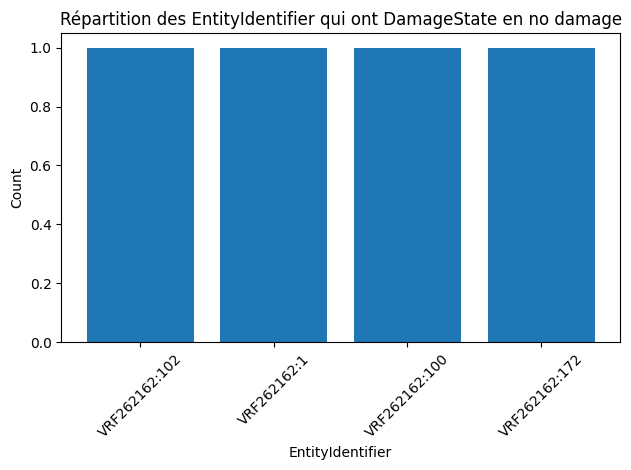


Graph sauvegardé dans: out78.png


In [9]:
run_llm_visualizer(
    file="data/lidata.log",
    prompt="Répartition des EntityIdentifier qui ont DamageState en no damage",
    out="out78.png"
)


INTENTION DETECTEE:
 {'intent': 'count', 'chart': 'auto', 'filter': [{'column': 'HasAmmunitionSupplyCap', 'value': False, 'op': '=='}]}

DEBUG INTENTION: {'intent': 'count', 'chart': 'auto', 'filter': [{'column': 'HasAmmunitionSupplyCap', 'value': False, 'op': '=='}]}
[debug] PlotSpec: PlotSpec(plot_type='single_count', x=None, y=None, group_by=None, filters=[{'column': 'HasAmmunitionSupplyCap', 'value': False, 'op': '=='}], sort_by=None, sort_ascending=False)


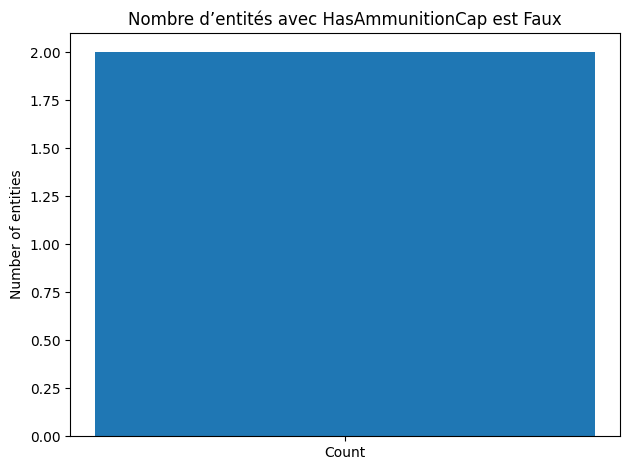


Graph sauvegardé dans: out.png


In [10]:
run_llm_visualizer(
    file="data/lidata.log",
    prompt="Nombre d’entités avec HasAmmunitionCap est Faux",
    out="out.png"
)


INTENTION DETECTEE:
 {'intent': 'distribution', 'chart': 'bar', 'group_by': 'EntityIdentifier', 'filter': [{'column': 'DamageState', 'value': 'no damage'}]}

DEBUG INTENTION: {'intent': 'distribution', 'chart': 'bar', 'group_by': 'EntityIdentifier', 'filter': [{'column': 'DamageState', 'value': 'no damage'}]}
[debug] PlotSpec: PlotSpec(plot_type='bar_count', x=None, y=None, group_by='EntityIdentifier', filters=[{'column': 'DamageState', 'value': 'no damage'}], sort_by='count', sort_ascending=False)


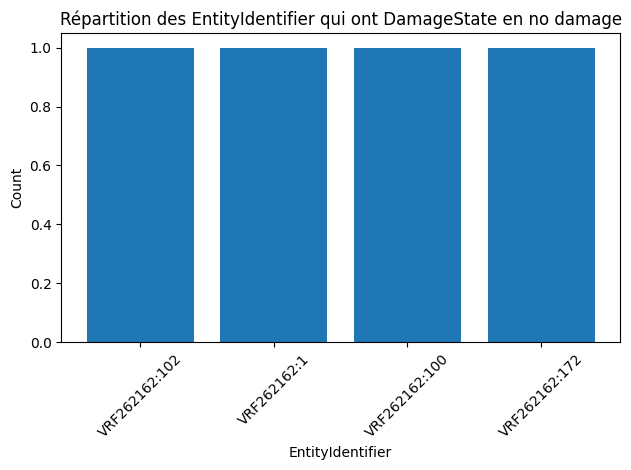


Graph sauvegardé dans: out8.png


In [11]:
run_llm_visualizer(
    file="data/lidata.log",
    prompt="Répartition des EntityIdentifier qui ont DamageState en no damage",
    out="out8.png"
)



INTENTION DETECTEE:
 {'intent': 'time_series', 'chart': 'line', 'x': 'SimTime', 'y': 'Spatial_FPB_WorldLocation_x'}

DEBUG INTENTION: {'intent': 'time_series', 'chart': 'line', 'x': 'SimTime', 'y': 'Spatial_FPB_WorldLocation_x'}
[debug] PlotSpec: PlotSpec(plot_type='line', x='SimTime', y='Spatial_FPB_WorldLocation_x', group_by=None, filters=[], sort_by='x', sort_ascending=True)


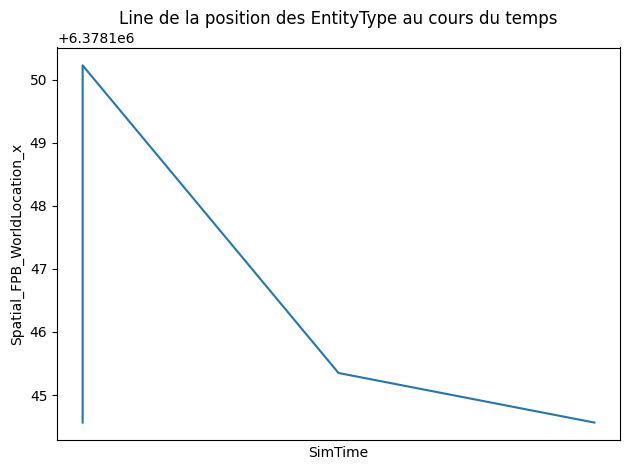


Graph sauvegardé dans: out10.png


In [12]:
run_llm_visualizer(
    file="data/lidata.log",
    prompt="Line de la position des EntityType au cours du temps",
    out="out10.png"
)